# Notebook 03 — Modélisation
## Projet : Aide à la commercialisation foncière — WISDOM International

Objectif : construire et évaluer un modèle prédisant le statut de
commercialisation des parcelles (vendu / disponible), en contrôlant
sa robustesse, puis produire un score exploitable pour le tableau de bord.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid")

# On recharge la base propre (Phase 1)
base = pd.read_csv("../02_donnees_propres/base_parcelles.csv")

# La cible : ce que le modèle doit prédire
y = base["vendu"]

print("Nombre de parcelles :", len(base))
print("Répartition de la cible :")
print(y.value_counts())
print(f"\nProportion de vendus : {y.mean()*100:.1f} %")

Nombre de parcelles : 408
Répartition de la cible :
vendu
1    358
0     50
Name: count, dtype: int64

Proportion de vendus : 87.7 %


In [2]:
# Variables explicatives légitimes (connues avant la vente)
X = base[["superficie", "bloc", "TF"]].copy()

print("Variables d'entrée retenues :", list(X.columns))
print("Dimensions de X :", X.shape)
X.head()

Variables d'entrée retenues : ['superficie', 'bloc', 'TF']
Dimensions de X : (408, 3)


,superficie,bloc,TF
0,500.0,4.0,5880
1,500.0,4.0,5880
2,500.0,4.0,5880
3,500.0,4.0,5880
4,500.0,4.0,5880


In [3]:
# On transforme bloc et TF en catégories, puis en colonnes binaires (one-hot)
X_encode = pd.get_dummies(X, columns=["bloc", "TF"], drop_first=True)

print("Nombre de colonnes après encodage :", X_encode.shape[1])
print("\nAperçu des premières colonnes :")
print(list(X_encode.columns[:8]))
X_encode.head()

Nombre de colonnes après encodage : 37

Aperçu des premières colonnes :
['superficie', 'bloc_2.0', 'bloc_3.0', 'bloc_4.0', 'bloc_5.0', 'bloc_6.0', 'bloc_7.0', 'bloc_8.0']


,superficie,bloc_2.0,bloc_3.0,bloc_4.0,bloc_5.0,bloc_6.0,bloc_7.0,bloc_8.0,bloc_9.0,bloc_10.0,...,TF_5216 nvo,TF_5262 KADJO,TF_5608,TF_5792 YANGA,TF_5880,TF_5880(02),TF_5881,TF_6037,TF_6428 LISSOM,TF_6428(4 et 9)
0,500.0,False,False,True,False,False,False,False,False,False,...,False,False,False,False,True,False,False,False,False,False
1,500.0,False,False,True,False,False,False,False,False,False,...,False,False,False,False,True,False,False,False,False,False
2,500.0,False,False,True,False,False,False,False,False,False,...,False,False,False,False,True,False,False,False,False,False
3,500.0,False,False,True,False,False,False,False,False,False,...,False,False,False,False,True,False,False,False,False,False
4,500.0,False,False,True,False,False,False,False,False,False,...,False,False,False,False,True,False,False,False,False,False


In [4]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_encode, y,
    test_size=0.25,      # 25 % des parcelles réservées au test
    random_state=42,     # pour obtenir toujours le même découpage
    stratify=y           # garder la même proportion vendu/disponible
)

print("Entraînement :", X_train.shape[0], "parcelles")
print("Test         :", X_test.shape[0], "parcelles")
print("\nProportion de vendus (entraînement) :", round(y_train.mean()*100, 1), "%")
print("Proportion de vendus (test)         :", round(y_test.mean()*100, 1), "%")

Entraînement : 306 parcelles
Test         : 102 parcelles

Proportion de vendus (entraînement) : 87.9 %
Proportion de vendus (test)         : 87.3 %


In [5]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, f1_score

# 1) Standardisation : on met toutes les variables à une échelle comparable
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)   # apprend les échelles SUR l'entraînement
X_test_s = scaler.transform(X_test)         # applique les MÊMES échelles au test

# 2) Entraînement du modèle
logreg = LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42)
logreg.fit(X_train_s, y_train)

# 3) Prédictions sur le test (probabilités, puis décision à 0,5)
proba_lr = logreg.predict_proba(X_test_s)[:, 1]
pred_lr = (proba_lr > 0.5).astype(int)

# 4) Performances
auc_lr = roc_auc_score(y_test, proba_lr)
f1_lr = f1_score(y_test, pred_lr)
print(f"Régression logistique  ->  AUC = {auc_lr:.3f}  |  F1 = {f1_lr:.3f}")

Régression logistique  ->  AUC = 0.871  |  F1 = 0.897


In [6]:
from sklearn.ensemble import RandomForestClassifier

# Entraînement (pas besoin de standardisation pour un Random Forest)
rf = RandomForestClassifier(
    n_estimators=200,            # 200 arbres
    class_weight="balanced",     # gestion du déséquilibre
    random_state=42
)
rf.fit(X_train, y_train)

# Prédictions sur le test
proba_rf = rf.predict_proba(X_test)[:, 1]
pred_rf = (proba_rf > 0.5).astype(int)

# Performances
auc_rf = roc_auc_score(y_test, proba_rf)
f1_rf = f1_score(y_test, pred_rf)
print(f"Random Forest  ->  AUC = {auc_rf:.3f}  |  F1 = {f1_rf:.3f}")

Random Forest  ->  AUC = 0.903  |  F1 = 0.960


In [7]:
from sklearn.model_selection import cross_val_score

# On teste le Random Forest sur 5 découpages différents des données
scores_cv = cross_val_score(
    rf, X_encode, y,
    cv=5,                # 5 découpages
    scoring="roc_auc"    # on mesure l'AUC à chaque fois
)

print("AUC sur chacun des 5 découpages :")
print(scores_cv.round(3))
print(f"\nAUC moyen : {scores_cv.mean():.3f}")
print(f"Écart-type : {scores_cv.std():.3f}")

AUC sur chacun des 5 découpages :
[0.75  0.822 0.393 0.534 0.535]

AUC moyen : 0.607
Écart-type : 0.157


In [8]:
# On reconstruit les variables SANS le bloc : superficie + lotissement seulement
X_sans_bloc = pd.get_dummies(base[["superficie", "TF"]], columns=["TF"], drop_first=True)

# Validation croisée du même modèle, sans le bloc
scores_sans_bloc = cross_val_score(
    RandomForestClassifier(n_estimators=200, class_weight="balanced", random_state=42),
    X_sans_bloc, y, cv=5, scoring="roc_auc"
)

print("Sans la variable bloc :")
print("AUC sur les 5 découpages :", scores_sans_bloc.round(3))
print(f"AUC moyen : {scores_sans_bloc.mean():.3f}")
print(f"Écart-type : {scores_sans_bloc.std():.3f}")

Sans la variable bloc :
AUC sur les 5 découpages : [0.734 0.983 0.276 0.517 0.476]
AUC moyen : 0.597
Écart-type : 0.242


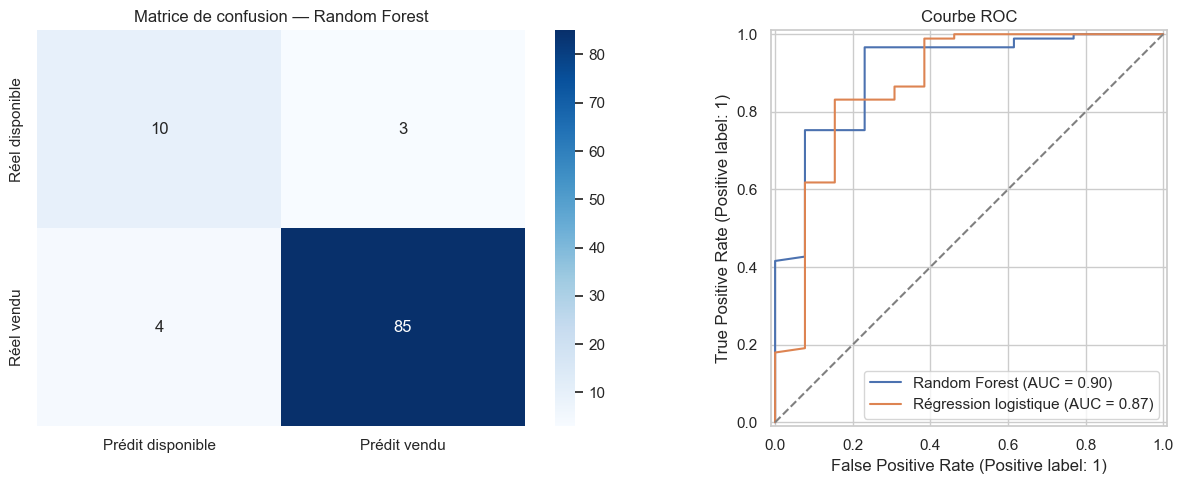

              precision    recall  f1-score   support

  Disponible       0.71      0.77      0.74        13
       Vendu       0.97      0.96      0.96        89

    accuracy                           0.93       102
   macro avg       0.84      0.86      0.85       102
weighted avg       0.93      0.93      0.93       102



In [9]:
from sklearn.metrics import confusion_matrix, classification_report, RocCurveDisplay

fig, ax = plt.subplots(1, 2, figsize=(13, 5))

# 1) Matrice de confusion
cm = confusion_matrix(y_test, pred_rf)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax[0],
            xticklabels=["Prédit disponible", "Prédit vendu"],
            yticklabels=["Réel disponible", "Réel vendu"])
ax[0].set_title("Matrice de confusion — Random Forest")

# 2) Courbe ROC des deux modèles
RocCurveDisplay.from_predictions(y_test, proba_rf, ax=ax[1], name="Random Forest")
RocCurveDisplay.from_predictions(y_test, proba_lr, ax=ax[1], name="Régression logistique")
ax[1].plot([0, 1], [0, 1], "--", color="grey")
ax[1].set_title("Courbe ROC")

plt.tight_layout()
plt.show()

# Rapport détaillé
print(classification_report(y_test, pred_rf, target_names=["Disponible", "Vendu"]))

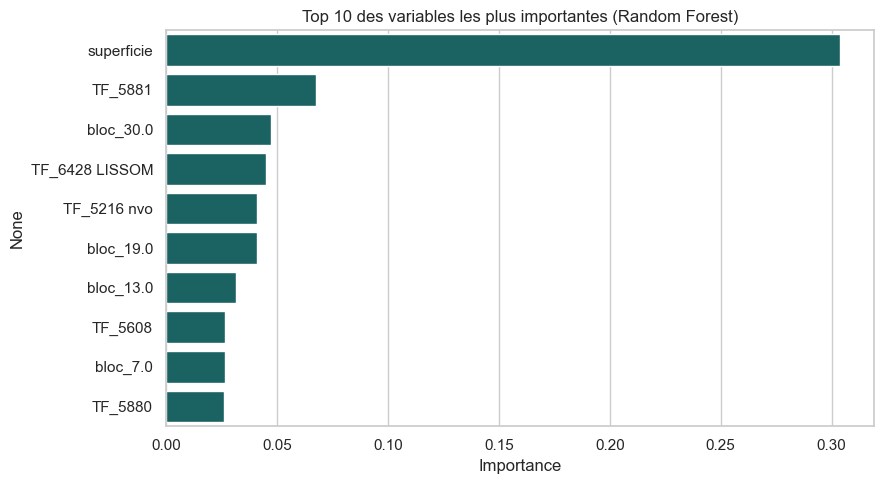

superficie        0.304
TF_5881           0.068
bloc_30.0         0.047
TF_6428 LISSOM    0.045
TF_5216 nvo       0.041
bloc_19.0         0.041
bloc_13.0         0.031
TF_5608           0.026
bloc_7.0          0.026
TF_5880           0.026
dtype: float64


In [10]:
# Le Random Forest indique le poids de chaque variable dans ses décisions
importances = pd.Series(rf.feature_importances_, index=X_encode.columns)
top10 = importances.sort_values(ascending=False).head(10)

plt.figure(figsize=(9, 5))
sns.barplot(x=top10.values, y=top10.index, color="#0F6E6E")
plt.title("Top 10 des variables les plus importantes (Random Forest)")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

print(top10.round(3))

In [11]:
# Score (probabilité de vente) pour TOUTES les parcelles
base_resultats = base.copy()
base_resultats["proba_vente"] = rf.predict_proba(X_encode)[:, 1].round(3)
base_resultats["score_sur_100"] = (base_resultats["proba_vente"] * 100).round(0).astype(int)

# Priorité commerciale pour les parcelles ENCORE disponibles
def priorite(ligne):
    if ligne["vendu"] == 1:
        return "Déjà vendu"
    if ligne["proba_vente"] >= 0.7:
        return "Forte (à conclure)"
    if ligne["proba_vente"] >= 0.4:
        return "Moyenne"
    return "À relancer"

base_resultats["priorite"] = base_resultats.apply(priorite, axis=1)

# Export pour Power BI
base_resultats.to_csv("../04_resultats/resultats_pour_powerbi.csv", index=False)
print("Fichier exporté : 04_resultats/resultats_pour_powerbi.csv")

# Aperçu : les lots disponibles, triés par priorité
apercu = base_resultats[base_resultats["vendu"] == 0].sort_values("score_sur_100", ascending=False)
apercu[["TF", "bloc", "lot", "superficie", "score_sur_100", "priorite"]].head(10)

Fichier exporté : 04_resultats/resultats_pour_powerbi.csv


,TF,bloc,lot,superficie,score_sur_100,priorite
296,5608,20.0,8.0,500.0,100,Forte (à conclure)
363,4192,3.0,2.0,432.0,91,Forte (à conclure)
228,3638(2),11.0,9.0,788.0,90,Forte (à conclure)
18,5880,6.0,13.0,500.0,62,Moyenne
274,5608,22.0,11.0,500.0,54,Moyenne
391,3989,8.0,4.0,500.0,45,Moyenne
147,5881,10.0,8.0,362.0,40,À relancer
367,4192,3.0,6.0,344.0,40,À relancer
384,6037,1.0,3.0,438.0,37,À relancer
110,5881,10.0,6.0,395.0,36,À relancer
